# Analyse exploratoire (EDA) de la table Casualty
**Données :** STATS19 du Department for Transport (Grande-Bretagne), victimes de collisions corporelles 2021-2025. **Une ligne = une victime.**

**Objectif :** comprendre le contenu de la table *avant* tout nettoyage, repérer les problèmes de qualité et justifier les choix de `clean_casualty.py`.

**Plan**
1. Chargement et structure
2. Clé, jointures et cohérence avec Collision
3. Valeurs manquantes (`-1`, `9`, `99`)
4. Valeurs « non applicable » (selon le type de victime)
5. Changements de saisie dans le temps
6. La cible : la gravité (`casualty_severity`)
7. Profil des victimes (type, âge, sexe)
8. Gravité selon le profil
9. Liens avec la gravité (V de Cramér)
10. Synthèse : constats → décisions de nettoyage

## 1. Chargement et structure

In [1]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60, "display.width", 200)

def find_file(keyword):
    for base in [Path("data_brut"), Path("../data_brut")]:
        files = sorted(p for p in base.glob(f"*{keyword}*") if p.suffix.lower() in (".zip", ".csv"))
        if files:
            return files[0]
    return None

def read_raw(path, usecols=None):
    if path.suffix.lower() == ".zip":
        with zipfile.ZipFile(path) as z:
            name = [n for n in z.namelist()
                    if n.lower().endswith(".csv") and not n.startswith("__MACOSX")][0]
            with z.open(name) as f:
                return pd.read_csv(f, low_memory=False, usecols=usecols)
    return pd.read_csv(path, low_memory=False, usecols=usecols)

DATA_PATH = find_file("casualty")
if DATA_PATH is None:
    raise FileNotFoundError("Placez le fichier casualty dans le dossier data_brut/")
print("Fichier utilisé :", DATA_PATH)

df = read_raw(DATA_PATH)
print(f"{df.shape[0]:,} lignes x {df.shape[1]} colonnes")
df.head(3)

Fichier utilisé : ../data_brut/dft-road-casualty-statistics-casualty-last-5-years.csv.zip


652,821 lignes x 24 colonnes


,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding,escooter_flag
0,2022522205219,2022,522205219,2,1,1,1,20,4,2,0,0,0,0,0,-1,4,E01033362,-1,0,1.0,0.0,-1,0
1,2021010288881,2021,010288881,1,1,3,2,7,2,2,9,6,0,0,0,0,1,E01004340,-1,0,1.0,0.0,-1,0
2,2021010288939,2021,010288939,1,1,3,1,21,5,3,8,4,0,0,0,0,3,E01001823,-1,0,0.0,1.0,-1,0


In [2]:
pd.DataFrame({
    "type": df.dtypes.astype(str),
    "valeurs_distinctes": df.nunique(),
    "NaN": df.isna().sum(),
    "exemple": df.iloc[0],
})

,type,valeurs_distinctes,NaN,exemple
collision_index,str,513801,0,2022522205219
collision_year,int64,5,0,2022
collision_ref_no,str,510837,0,522205219
vehicle_reference,int64,38,0,2
casualty_reference,int64,145,0,1
casualty_class,int64,3,0,1
sex_of_casualty,int64,4,0,1
age_of_casualty,int64,104,0,20
age_band_of_casualty,int64,12,0,4
casualty_severity,int64,3,0,2


**Lecture :** 24 colonnes, presque toutes des **codes** (catégories). Aucun `NaN` : les manquants sont cachés sous des codes (`-1`, `9`, `99`). La table décrit la victime (classe, sexe, âge, type, gravité) ; elle ne contient ni la date ni le lieu de la collision, qui sont dans la table Collision.

## 2. Clé, jointures et cohérence avec Collision

In [3]:
key = ["collision_index", "casualty_reference"]
print("Clé (collision_index, casualty_reference) unique :", not df.duplicated(key).any())
print("Lignes dupliquées (toutes colonnes)            :", df.duplicated().sum())
print("Collisions distinctes dans Casualty            :", df["collision_index"].nunique())

per_coll = df.groupby("collision_index").size()
print(f"Collisions avec 1 seule victime : {(per_coll == 1).mean()*100:.1f} %")
display(per_coll.clip(upper=6).value_counts().sort_index().rename("collisions").to_frame()
        .rename(index={6: "6 ou plus"}).T)

# Contrôle croisé avec la table Collision (si elle est dans data_brut/)
coll_path = find_file("collision")
if coll_path is not None:
    coll = read_raw(coll_path, usecols=["collision_index", "number_of_casualties"]).set_index("collision_index")
    ecart = (per_coll.reindex(coll.index).fillna(0).astype(int) != coll["number_of_casualties"]).sum()
    print("Collision.number_of_casualties vs lignes de Casualty : écarts =", ecart)
else:
    print("(Table Collision non trouvée dans data_brut : contrôle croisé ignoré)")

Clé (collision_index, casualty_reference) unique : True


Lignes dupliquées (toutes colonnes)            : 0
Collisions distinctes dans Casualty            : 513801


Collisions avec 1 seule victime : 81.5 %


,1,2,3,4,5,6 ou plus
collisions,418798,67034,18180,6258,2303,1228


Collision.number_of_casualties vs lignes de Casualty : écarts = 0


**Lecture :** la clé `(collision_index, casualty_reference)` est unique, et le nombre de victimes par collision correspond exactement à `number_of_casualties` de la table Collision : les deux tables sont **parfaitement cohérentes**. Environ 4 collisions sur 5 n'ont qu'une victime.

## 3. Valeurs manquantes (`-1`, `9`, `99`)

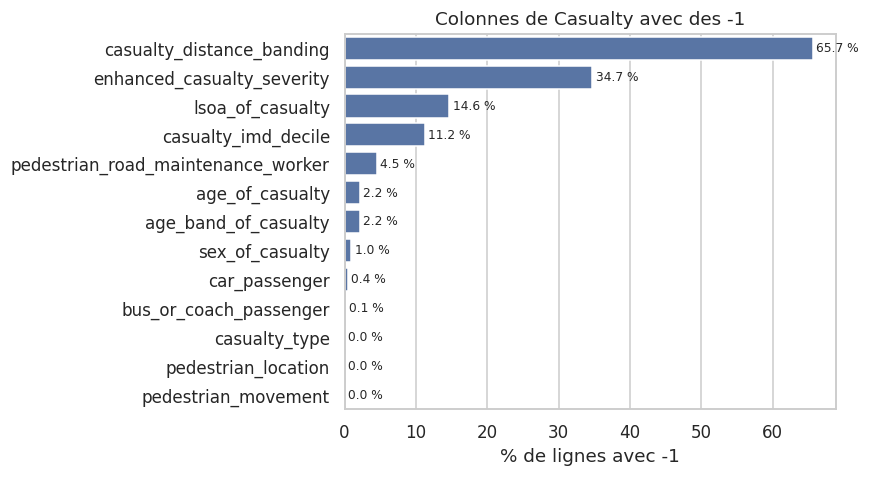

In [4]:
def pct_minus1(s):
    if pd.api.types.is_numeric_dtype(s):
        return (s == -1).mean() * 100
    return s.astype(str).eq("-1").mean() * 100

miss = df.apply(pct_minus1).sort_values(ascending=False)
top = miss[miss > 0]

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=top.values, y=top.index, color="#4C72B0", ax=ax)
ax.set_xlabel("% de lignes avec -1"); ax.set_ylabel("")
ax.set_title("Colonnes de Casualty avec des -1")
for i, v in enumerate(top.values):
    ax.text(v + 0.5, i, f"{v:.1f} %", va="center", fontsize=8)
plt.tight_layout(); plt.show()

In [5]:
# Piège : 9 et 99 ne sont PAS des manquants partout
print("casualty_type = 9  :", f"{(df['casualty_type']==9).sum():,}", "lignes -> occupant de voiture (valeur normale, la plus fréquente)")
print("casualty_type = 99 :", (df['casualty_type']==99).sum(), "lignes -> inconnu (manquant)")
print("age_of_casualty = 99 :", (df['age_of_casualty']==99).sum(), "lignes -> personnes de 99 ans (valeur réelle)")
print("age_band_of_casualty = 9 :", f"{(df['age_band_of_casualty']==9).sum():,}", "lignes -> tranche 56-65 ans (valeur réelle)")
print("casualty_imd_decile = 9  :", f"{(df['casualty_imd_decile']==9).sum():,}", "lignes -> décile 9 (valeur réelle)")
print("sex_of_casualty = 9 :", (df['sex_of_casualty']==9).sum(), "lignes -> inconnu (manquant)")
print()
print("Sexe, âge et tranche d'âge manquants : mêmes lignes pour âge et tranche ->",
      ((df['age_of_casualty'] == -1) == (df['age_band_of_casualty'] == -1)).all())
print("casualty_imd_decile = -1 avec lsoa_of_casualty = -1 :",
      ((df['casualty_imd_decile'] == -1) & (df['lsoa_of_casualty'] == '-1')).sum(), "sur", (df['casualty_imd_decile'] == -1).sum())

casualty_type = 9  : 347,393 lignes -> occupant de voiture (valeur normale, la plus fréquente)
casualty_type = 99 : 33 lignes -> inconnu (manquant)
age_of_casualty = 99 : 18 lignes -> personnes de 99 ans (valeur réelle)
age_band_of_casualty = 9 : 64,371 lignes -> tranche 56-65 ans (valeur réelle)
casualty_imd_decile = 9  : 44,577 lignes -> décile 9 (valeur réelle)
sex_of_casualty = 9 : 129 lignes -> inconnu (manquant)

Sexe, âge et tranche d'âge manquants : mêmes lignes pour âge et tranche -> True
casualty_imd_decile = -1 avec lsoa_of_casualty = -1 : 73236 sur 73236


**Lecture :**
- `casualty_imd_decile` (11 %) et `lsoa_of_casualty` (14,6 %) sont les plus touchées. Tous les déciles manquants correspondent à un LSOA manquant : on ne peut donc pas les reconstituer par le LSOA.
- `casualty_distance_banding` est à `-1` pour 66 % des lignes : voir section 5.
- L'âge est manquant pour 2,2 % des lignes (14 106) et le sexe pour 1 % (6 433, en comptant le code `9`).
- **Piège à éviter :** convertir tous les `9` et `99` en manquants détruirait par exemple les occupants de voiture (`casualty_type = 9`, 53 % de la table).

## 4. Valeurs « non applicable » selon le type de victime

In [6]:
cls = {1: "Conducteur / motard", 2: "Passager", 3: "Piéton"}
for col in ["car_passenger", "bus_or_coach_passenger", "pedestrian_road_maintenance_worker"]:
    print(col)
    display(pd.crosstab(df[col], df["casualty_class"].map(cls)))

car_passenger


casualty_class,Conducteur / motard,Passager,Piéton
car_passenger,,,
-1,63,2862,1
0,431565,17067,94396
1,1138,65350,0
2,116,39583,1
9,1,678,0


bus_or_coach_passenger


casualty_class,Conducteur / motard,Passager,Piéton
bus_or_coach_passenger,,,
-1,126,378,11
0,432757,115738,94387
1,0,408,0
2,0,514,0
3,0,2557,0
4,0,5838,0
9,0,107,0


pedestrian_road_maintenance_worker


casualty_class,Conducteur / motard,Passager,Piéton
pedestrian_road_maintenance_worker,,,
-1,0,0,29440
0,432883,125540,57732
1,0,0,689
2,0,0,6537


In [7]:
# Les colonnes "piéton" valent 0 pour tous les non-piétons
ped_cols = ["pedestrian_location", "pedestrian_movement"]
print("Part de 0 chez les non-piétons :")
print((df.loc[df["casualty_class"] != 3, ped_cols] == 0).mean().round(4).to_dict())
print("\nChez les piétons, codes 'inconnu ou autre' (10 pour location, 9 pour movement) :")
print({"pedestrian_location=10": f"{(df.loc[df.casualty_class==3,'pedestrian_location']==10).mean()*100:.1f} %",
       "pedestrian_movement=9": f"{(df.loc[df.casualty_class==3,'pedestrian_movement']==9).mean()*100:.1f} %"})

Part de 0 chez les non-piétons :
{'pedestrian_location': 1.0, 'pedestrian_movement': 1.0}

Chez les piétons, codes 'inconnu ou autre' (10 pour location, 9 pour movement) :
{'pedestrian_location=10': '9.7 %', 'pedestrian_movement=9': '28.8 %'}


**Lecture :**
- `car_passenger` et `bus_or_coach_passenger` n'ont de sens que pour les **passagers**. Un `-1` chez un conducteur ou un piéton (64 et 137 lignes) veut dire « non concerné », pas « manquant » : on le recode en 0. Un `-1` chez un vrai passager est un vrai manquant (2 862 et 378 lignes).
- `pedestrian_location` / `pedestrian_movement` valent 0 pour tous les non-piétons : le code 0 est « pas un piéton ». Les rares `-1` (environ 50) concernent des piétons.
- `pedestrian_road_maintenance_worker` : 31 % des piétons sont à `-1` et seulement 689 piétons sont « oui » (0,7 %) : colonne peu informative.
- Chez les piétons, les codes « inconnu ou autre » sont très fréquents (surtout pour le mouvement, environ 29 %) : on les garde comme catégorie, car ils mélangent « inconnu » et « autre ».

## 5. Changements de saisie dans le temps

,victimes,injury_based (%),enhanced_severity = -1 (%),distance_banding = -1 (%),% graves (gravité brute),% graves (gravité ajustée)
collision_year,,,,,,
2021,128209,51.7,48.3,100.0,18.2,19.4
2022,135480,54.6,45.4,100.0,19.1,20.1
2023,132977,55.8,44.2,100.0,19.6,20.6
2024,128272,79.1,20.9,13.5,20.3,21.3
2025,127883,86.4,13.6,11.5,21.7,22.2


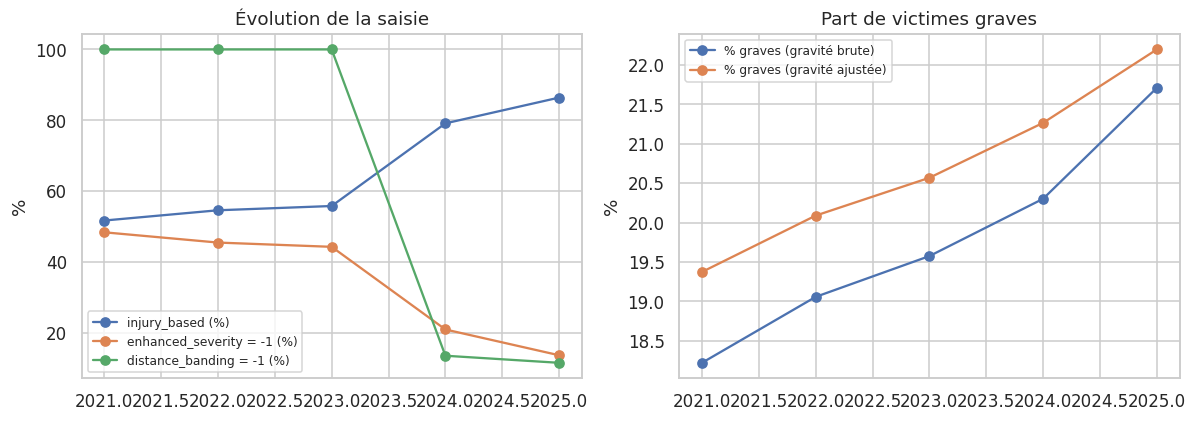

In [8]:
by_year = pd.DataFrame({
    "victimes": df.groupby("collision_year").size(),
    "injury_based (%)": df.groupby("collision_year")["casualty_injury_based"].mean() * 100,
    "enhanced_severity = -1 (%)": df.groupby("collision_year")["enhanced_casualty_severity"].apply(lambda s: (s == -1).mean() * 100),
    "distance_banding = -1 (%)": df.groupby("collision_year")["casualty_distance_banding"].apply(lambda s: (s == -1).mean() * 100),
    "% graves (gravité brute)": df.groupby("collision_year")["casualty_severity"].apply(lambda s: (s == 2).mean() * 100),
    "% graves (gravité ajustée)": df.groupby("collision_year")["casualty_adjusted_severity_serious"].mean() * 100,
})
display(by_year.round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
by_year[["injury_based (%)", "enhanced_severity = -1 (%)", "distance_banding = -1 (%)"]].plot(marker="o", ax=axes[0])
axes[0].set_title("Évolution de la saisie"); axes[0].set_ylabel("%"); axes[0].set_xlabel(""); axes[0].legend(fontsize=8)
by_year[["% graves (gravité brute)", "% graves (gravité ajustée)"]].plot(marker="o", ax=axes[1])
axes[1].set_title("Part de victimes graves"); axes[1].set_ylabel("%"); axes[1].set_xlabel(""); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [9]:
print("Part de victimes graves selon casualty_injury_based :")
print((df.groupby("casualty_injury_based")["casualty_severity"].apply(lambda s: (s == 2).mean()) * 100).round(1))
print()
print("casualty_distance_banding par année (codes 1 à 5 = distance domicile-lieu de la collision) :")
pd.crosstab(df["collision_year"], df["casualty_distance_banding"])

Part de victimes graves selon casualty_injury_based :
casualty_injury_based
0    16.3
1    21.6
Name: casualty_severity, dtype: float64

casualty_distance_banding par année (codes 1 à 5 = distance domicile-lieu de la collision) :


casualty_distance_banding,-1,1,2,3,4,5
collision_year,,,,,,
2021,128209,0,0,0,0,0
2022,135480,0,0,0,0,0
2023,132977,0,0,0,0,0
2024,17275,62711,17359,13438,13653,3836
2025,14663,63937,17557,13604,14070,4052


**Lecture :**
- Même changement de saisie que dans Collision : la part « injury-based » passe d'environ 52 % (2021) à 86 % (2025), et `enhanced_casualty_severity` est de moins en moins à `-1`.
- `casualty_distance_banding` n'existe qu'à partir de **2024** : 100 % de `-1` de 2021 à 2023. Même en 2024-2025, 11 à 14 % des lignes restent à `-1`. Impossible à imputer honnêtement sur 66 % de la table.
- Les victimes « injury-based » sont plus souvent classées graves (21,6 % contre 16,3 %). La part de graves monte de 18,2 % à 21,7 % en gravité brute ; la gravité **ajustée** monte aussi (19,4 % à 22,2 %), un peu moins. Comme pour Collision : une partie de la hausse vient peut-être du changement de méthode, sans preuve qu'elle explique tout.

## 6. La cible : la gravité

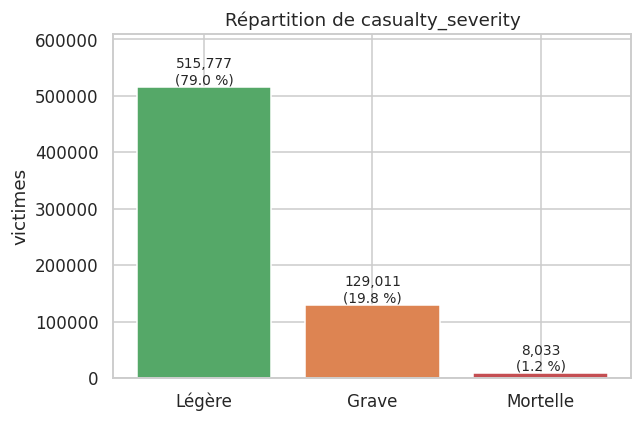

In [10]:
sev_labels = {1: "Mortelle", 2: "Grave", 3: "Légère"}
sev = df["casualty_severity"].map(sev_labels).value_counts().reindex(["Légère", "Grave", "Mortelle"])
pct = (sev / sev.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sev.index, sev.values, color=["#55A868", "#DD8452", "#C44E52"])
for i, (v, p) in enumerate(zip(sev.values, pct.values)):
    ax.text(i, v, f"{v:,}\n({p} %)", ha="center", va="bottom", fontsize=9)
ax.set_title("Répartition de casualty_severity")
ax.set_ylabel("victimes"); ax.set_ylim(0, sev.max() * 1.18)
plt.tight_layout(); plt.show()

**Lecture :** cible **déséquilibrée** : environ 79 % de victimes légères, 20 % graves et 1,2 % mortelles (8 033 victimes). Ces proportions sont différentes de celles de Collision, car ici on compte les victimes et non les collisions. La classe « mortelle » est rare : il faudra pondérer les classes ou rééchantillonner, et suivre le rappel par classe.

## 7. Profil des victimes

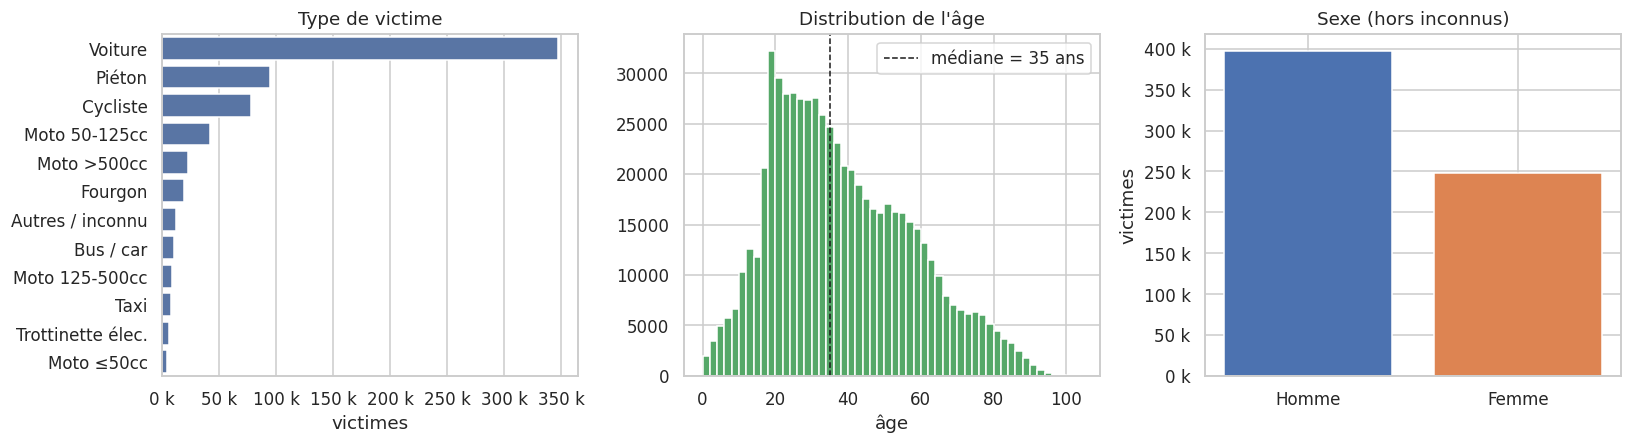

In [11]:
type_labels = {0: "Piéton", 1: "Cycliste", 2: "Moto ≤50cc", 3: "Moto 50-125cc", 4: "Moto 125-500cc",
               5: "Moto >500cc", 8: "Taxi", 9: "Voiture", 11: "Bus / car", 19: "Fourgon", 33: "Trottinette élec."}
t = df["casualty_type"].map(type_labels).fillna("Autres / inconnu").value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.barplot(x=t.values, y=t.index, color="#4C72B0", ax=axes[0])
axes[0].set_title("Type de victime"); axes[0].set_xlabel("victimes"); axes[0].set_ylabel("")

ages = df.loc[df["age_of_casualty"] >= 0, "age_of_casualty"]
axes[1].hist(ages, bins=range(0, 106, 2), color="#55A868")
axes[1].axvline(ages.median(), color="k", ls="--", lw=1, label=f"médiane = {ages.median():.0f} ans")
axes[1].set_title("Distribution de l'âge"); axes[1].set_xlabel("âge"); axes[1].legend()

s = df["sex_of_casualty"].map({1: "Homme", 2: "Femme"}).value_counts()
axes[2].bar(s.index, s.values, color=["#4C72B0", "#DD8452"])
axes[2].set_title("Sexe (hors inconnus)"); axes[2].set_ylabel("victimes")
from matplotlib.ticker import FuncFormatter
fmt = FuncFormatter(lambda v, _: f"{int(v/1000)} k")
axes[0].xaxis.set_major_formatter(fmt); axes[2].yaxis.set_major_formatter(fmt)
plt.tight_layout(); plt.show()

In [12]:
print("Âge : médiane par classe de victime (hors -1)")
print(df[df.age_of_casualty >= 0].groupby(df["casualty_class"].map(cls))["age_of_casualty"].median())
print()
print("Part d'hommes selon le type (hors sexe inconnu) :")
d = df[df.sex_of_casualty.isin([1, 2]) & df.casualty_type.isin(type_labels)]
(d.groupby(d["casualty_type"].map(type_labels))["sex_of_casualty"].apply(lambda s: (s == 1).mean() * 100)
  .round(0).loc[["Piéton", "Cycliste", "Moto 50-125cc", "Moto >500cc", "Voiture"]])

Âge : médiane par classe de victime (hors -1)


casualty_class
Conducteur / motard    37.0
Passager               27.0
Piéton                 33.0
Name: age_of_casualty, dtype: float64

Part d'hommes selon le type (hors sexe inconnu) :


casualty_type
Piéton           55.0
Cycliste         81.0
Moto 50-125cc    90.0
Moto >500cc      92.0
Voiture          51.0
Name: sex_of_casualty, dtype: float64

**Lecture :**
- Plus de la moitié des victimes sont des **occupants de voiture** (53 %), puis des piétons (14,5 %) et des cyclistes (12 %).
- L'âge médian est de 35 ans, avec un pic marqué vers 18-20 ans. Les passagers sont plus jeunes (médiane 27 ans) que les conducteurs (37 ans).
- 61 % des victimes sont des hommes, mais très inégalement selon le type : environ 81 % chez les cyclistes, 90 à 92 % chez les motards, 51 % chez les occupants de voiture.
- C'est pourquoi l'imputation de l'âge et du sexe se fait **par type de victime** et non globalement.

## 8. Gravité selon le profil

Taux global de victimes graves ou mortelles : 21.0 %


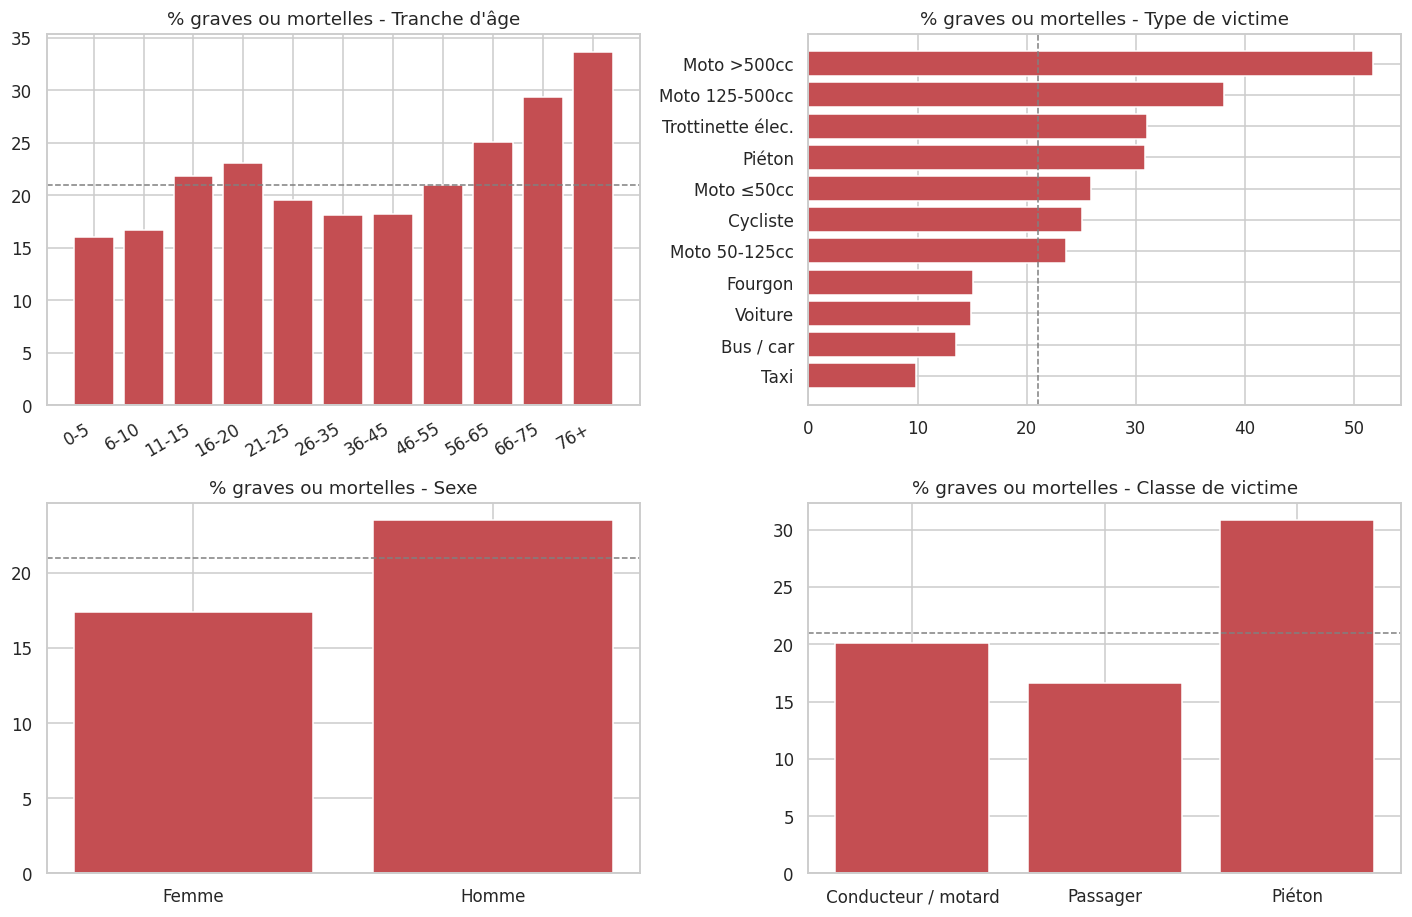

In [13]:
df["grave_ou_mortelle"] = (df["casualty_severity"] <= 2).astype(int)
global_rate = df["grave_ou_mortelle"].mean() * 100
print(f"Taux global de victimes graves ou mortelles : {global_rate:.1f} %")

band_labels = {1: "0-5", 2: "6-10", 3: "11-15", 4: "16-20", 5: "21-25", 6: "26-35",
               7: "36-45", 8: "46-55", 9: "56-65", 10: "66-75", 11: "76+"}
panels = []
d = df[df.age_band_of_casualty != -1]
panels.append(("Tranche d'âge", d.groupby(d["age_band_of_casualty"].map(band_labels))["grave_ou_mortelle"].mean() * 100,
               list(band_labels.values())))
d = df[df.casualty_type.isin(type_labels)]
r = d.groupby(d["casualty_type"].map(type_labels))["grave_ou_mortelle"].mean() * 100
panels.append(("Type de victime", r.sort_values(), None))
d = df[df.sex_of_casualty.isin([1, 2])]
panels.append(("Sexe", d.groupby(d["sex_of_casualty"].map({1: "Homme", 2: "Femme"}))["grave_ou_mortelle"].mean() * 100, None))
panels.append(("Classe de victime", df.groupby(df["casualty_class"].map(cls))["grave_ou_mortelle"].mean() * 100, None))

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for ax, (title, r, order) in zip(axes.ravel(), panels):
    r = r.reindex(order) if order else r
    if title == "Type de victime":
        ax.barh(r.index, r.values, color="#C44E52")
    else:
        ax.bar(r.index, r.values, color="#C44E52")
        plt.setp(ax.get_xticklabels(), rotation=0 if len(r) < 5 else 30, ha="center" if len(r) < 5 else "right")
    (ax.axvline if title == "Type de victime" else ax.axhline)(global_rate, color="grey", ls="--", lw=1)
    ax.set_title(f"% graves ou mortelles - {title}"); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

In [14]:
# Détail : part de mortelles selon le type de victime
d = df[df.casualty_type.isin(type_labels)]
(d.groupby(d["casualty_type"].map(type_labels))
   .agg(victimes=("casualty_severity", "size"),
        pct_graves_ou_mortelles=("grave_ou_mortelle", lambda s: round(s.mean() * 100, 1)),
        pct_mortelles=("casualty_severity", lambda s: round((s == 1).mean() * 100, 1)))
   .sort_values("pct_graves_ou_mortelles", ascending=False))

,victimes,pct_graves_ou_mortelles,pct_mortelles
casualty_type,,,
Moto >500cc,22542,51.7,5.0
Moto 125-500cc,9060,38.1,2.0
Trottinette élec.,5719,31.0,0.7
Piéton,94398,30.8,2.0
Moto ≤50cc,4397,25.9,0.4
Cycliste,77741,25.1,0.6
Moto 50-125cc,41840,23.6,0.8
Fourgon,19135,15.1,1.0
Voiture,347393,14.9,1.0


**Lecture :** (la ligne pointillée est le taux global, 21,0 %)
- **Type :** les motards de grosse cylindrée sont de loin les plus exposés (51,7 % de graves ou mortelles, 5 % de mortelles), devant les motos 125-500cc (38 %), les piétons (30,8 %, dont 2 % de mortelles) et les cyclistes (25 %). Les occupants de voiture (14,9 %) et de bus (13,6 %) sont beaucoup moins touchés : on le comprend, ils sont protégés.
- **Âge :** le taux est le plus bas chez les 0-10 ans (~16 %), puis augmente nettement après 55 ans (25 % pour 56-65, 29 % pour 66-75, 34 % au-delà de 75 ans). Un second sommet apparaît chez les 16-20 ans (23 %).
- **Sexe :** 23,5 % chez les hommes contre 17,4 % chez les femmes ; une grande partie de cet écart vient sans doute du type de véhicule (motards majoritairement masculins).
- **Classe :** les piétons sont les plus touchés (30,8 %), devant les conducteurs (20,1 %) et les passagers (16,6 %).

## 9. Liens avec la gravité (V de Cramér)

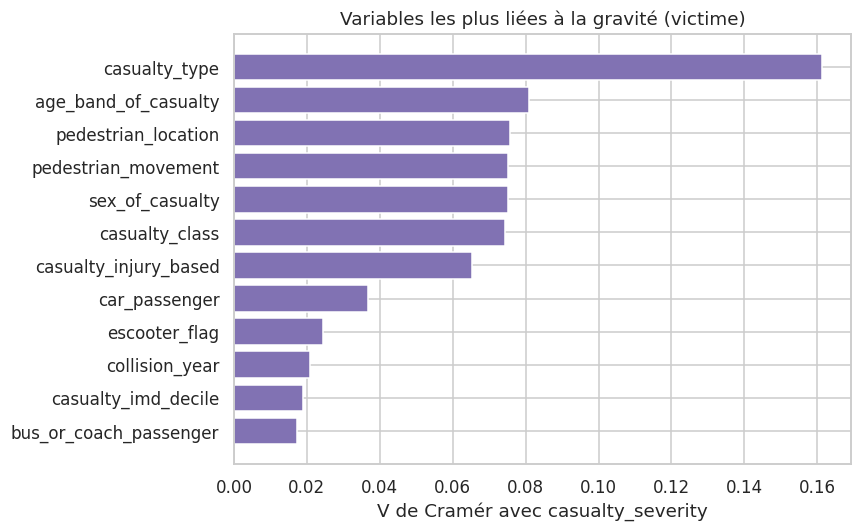

In [15]:
def cramers_v(x, y):
    t = pd.crosstab(x, y)
    chi2 = chi2_contingency(t)[0]
    n = t.values.sum()
    r, k = t.shape
    phi2c = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2c / min(kc - 1, rc - 1))

candidates = {  # variable : codes à exclure (manquants)
    "casualty_type": [-1, 99], "casualty_class": [], "age_band_of_casualty": [-1],
    "sex_of_casualty": [-1, 9], "pedestrian_location": [-1], "pedestrian_movement": [-1],
    "casualty_injury_based": [], "collision_year": [], "casualty_imd_decile": [-1],
    "car_passenger": [-1, 9], "bus_or_coach_passenger": [-1, 9], "escooter_flag": [],
}
res = {}
for c, bad in candidates.items():
    d = df[~df[c].isin(bad)]
    res[c] = cramers_v(d[c], d["casualty_severity"])
res = pd.Series(res).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(res.index, res.values, color="#8172B3")
ax.set_xlabel("V de Cramér avec casualty_severity")
ax.set_title("Variables les plus liées à la gravité (victime)")
plt.tight_layout(); plt.show()

**Lecture :**
- Toutes les associations sont **faibles** (V < 0,17). Le type de victime est le plus lié (V ≈ 0,16), puis la tranche d'âge (0,08), le sexe et la classe (≈ 0,07).
- Les colonnes `pedestrian_location` et `pedestrian_movement` sont surtout un reflet de « être piéton » (la grande majorité des lignes valent 0).
- Le décile de défavorisation (`casualty_imd_decile`) n'a quasiment aucun lien avec la gravité (V ≈ 0,02), de même que l'année.
- Pour mieux prédire la gravité, il faudra enrichir avec la table Vehicle (vitesse, type de véhicule, point d'impact) et la table Collision (limite de vitesse, zone, lumière).

## 10. Synthèse : constats → décisions de nettoyage

| Constat (EDA) | Décision dans `clean_casualty.py` |
|---|---|
| Clé `(collision_index, casualty_reference)` unique ; cohérence parfaite avec Collision | Conserver les clés ; contrôle croisé optionnel avec `--collision` |
| `collision_ref_no` non unique | Suppression |
| Manquants cachés sous `-1`, `9`, `99`, **sauf** `casualty_type = 9`, `age = 99`, `age_band = 9`, `imd = 9` qui sont de vraies valeurs | Conversion en `NaN` colonne par colonne |
| `-1` chez un non-passager (`car_passenger`, `bus_or_coach_passenger`) = non concerné | Recodé en 0 |
| `casualty_distance_banding` : 100 % de `-1` en 2021-2023 | Suppression |
| `enhanced_casualty_severity` : 35 % de `-1`, proche de la cible | Suppression |
| `pedestrian_road_maintenance_worker` : 31 % de `-1` chez les piétons, 0,7 % de « oui » | Suppression |
| Âge manquant (2,2 %) : variable continue, âge très différent selon le type de victime | **Médiane par `casualty_type`** + indicateur `age_imputed` |
| Sexe, `car_passenger`, `bus_or_coach_passenger`, `casualty_type`, `pedestrian_*` manquants | **Mode par groupe** (type ou classe de victime) |
| `casualty_imd_decile` manquant à 11 % (même lignes que LSOA manquant), décile ordinal | **Médiane globale** + indicateur `imd_missing` (à éviter pour l'analyse fine) |
| `lsoa_of_casualty` manquant (14,6 %) | Pas d'imputation, reste `NaN` |
| `age_band_of_casualty` doit rester cohérent avec l'âge | Recalculée à partir de l'âge complété |
| Cible déséquilibrée (mortelle 1,2 %), saisie qui change | À traiter à la modélisation ; utiliser aussi la gravité ajustée |
| Besoin d'une variable « usager vulnérable » | `is_vulnerable_user` (piétons, vélos, 2-roues motorisés, trottinettes) |

**Limites :** seule la table Casualty est analysée ; seules les victimes de collisions corporelles déclarées à la police sont recensées ; une association (V de Cramér) n'est pas une causalité ; imputer l'âge ou le sexe par le mode ou la médiane d'un groupe réduit légèrement la variabilité.